In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

import joblib

In [2]:
# Load preprocessed dataset
df = pd.read_csv("../data/preprocessed_data.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (99460, 18)


,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,Year,Month,Day,Week,Quarter,DayOfWeek,Weekend,Season
0,109318,C,7,80.079844,2025-12-26 12:32:00,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764,2025,12,26,52,4,Friday,False,Winter
1,993229,C,4,75.195229,2025-08-05 00:00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546,2025,8,5,32,3,Tuesday,False,Monsoon
2,579675,A,8,31.528816,2026-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651,2026,3,11,11,1,Wednesday,False,Summer
3,799826,D,5,98.880218,2025-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769,2025,10,27,44,4,Monday,False,Autumn
4,121413,A,7,93.188512,2025-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484,2025,12,22,52,4,Monday,False,Winter


In [3]:
# Convert TransactionDate to datetime
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"],format="mixed")

# Sort chronologically
df = df.sort_values("TransactionDate").reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99460 entries, 0 to 99459
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   CustomerID          99460 non-null  int64         
 1   ProductID           99460 non-null  str           
 2   Quantity            99460 non-null  int64         
 3   Price               99460 non-null  float64       
 4   TransactionDate     99460 non-null  datetime64[us]
 5   PaymentMethod       99460 non-null  str           
 6   StoreLocation       99460 non-null  str           
 7   ProductCategory     99460 non-null  str           
 8   DiscountApplied(%)  99460 non-null  float64       
 9   TotalAmount         99460 non-null  float64       
 10  Year                99460 non-null  int64         
 11  Month               99460 non-null  int64         
 12  Day                 99460 non-null  int64         
 13  Week                99460 non-null  int64         
 14  Q

In [4]:
daily_sales = (
    df.groupby("TransactionDate")["TotalAmount"]
      .sum()
      .reset_index()
)

daily_sales.head()

,TransactionDate,TotalAmount
0,2025-04-29 22:27:00,176.102880
1,2025-04-29 22:29:00,416.546875
2,2025-04-29 22:39:00,216.950602
3,2025-04-29 22:45:00,426.845208
4,2025-04-29 22:53:00,101.662372


In [5]:
forecast_df = daily_sales.copy()

# -----------------------------
# Calendar Features
# -----------------------------

forecast_df["Year"] = forecast_df["TransactionDate"].dt.year
forecast_df["Month"] = forecast_df["TransactionDate"].dt.month
forecast_df["Quarter"] = forecast_df["TransactionDate"].dt.quarter
forecast_df["WeekOfYear"] = forecast_df["TransactionDate"].dt.isocalendar().week.astype(int)
forecast_df["Day"] = forecast_df["TransactionDate"].dt.day
forecast_df["DayOfWeek"] = forecast_df["TransactionDate"].dt.dayofweek
forecast_df["DayOfYear"] = forecast_df["TransactionDate"].dt.dayofyear

forecast_df["IsWeekend"] = (
    forecast_df["DayOfWeek"] >= 5
).astype(int)


# -----------------------------
# Lag Features
# -----------------------------

forecast_df["Lag_1"] = forecast_df["TotalAmount"].shift(1)
forecast_df["Lag_2"] = forecast_df["TotalAmount"].shift(2)
forecast_df["Lag_3"] = forecast_df["TotalAmount"].shift(3)

forecast_df["Lag_7"] = forecast_df["TotalAmount"].shift(7)
forecast_df["Lag_14"] = forecast_df["TotalAmount"].shift(14)
forecast_df["Lag_30"] = forecast_df["TotalAmount"].shift(30)


# -----------------------------
# Rolling Mean Features
# -----------------------------

forecast_df["RollingMean_3"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(3)
    .mean()
)

forecast_df["RollingMean_7"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(7)
    .mean()
)

forecast_df["RollingMean_14"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(14)
    .mean()
)


# -----------------------------
# Rolling Std Features
# -----------------------------

forecast_df["RollingStd_7"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(7)
    .std()
)

forecast_df["RollingStd_14"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(14)
    .std()
)


# -----------------------------
# Trend Features
# -----------------------------

forecast_df["ExpandingMean"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .expanding()
    .mean()
)

forecast_df["SalesChange"] = (
    forecast_df["TotalAmount"]
    .diff()
)

forecast_df["SalesChangePercent"] = (
    forecast_df["TotalAmount"]
    .pct_change()
)

forecast_df.head(20)

,TransactionDate,TotalAmount,Year,Month,Quarter,WeekOfYear,Day,DayOfWeek,DayOfYear,IsWeekend,...,Lag_14,Lag_30,RollingMean_3,RollingMean_7,RollingMean_14,RollingStd_7,RollingStd_14,ExpandingMean,SalesChange,SalesChangePercent
0,2025-04-29 22:27:00,176.102880,2025,4,2,18,29,1,119,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-29 22:29:00,416.546875,2025,4,2,18,29,1,119,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,176.102880,240.443995,1.365361
2,2025-04-29 22:39:00,216.950602,2025,4,2,18,29,1,119,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,296.324878,-199.596273,-0.479169
3,2025-04-29 22:45:00,426.845208,2025,4,2,18,29,1,119,0,...,NaN,NaN,269.866786,NaN,NaN,NaN,NaN,269.866786,209.894606,0.967476
4,2025-04-29 22:53:00,101.662372,2025,4,2,18,29,1,119,0,...,NaN,NaN,353.447562,NaN,NaN,NaN,NaN,309.111391,-325.182836,-0.761828
5,2025-04-29 23:02:00,270.745091,2025,4,2,18,29,1,119,0,...,NaN,NaN,248.486061,NaN,NaN,NaN,NaN,267.621588,169.082719,1.663179
6,2025-04-29 23:15:00,53.510366,2025,4,2,18,29,1,119,0,...,NaN,NaN,266.417557,NaN,NaN,NaN,NaN,268.142172,-217.234726,-0.802359
7,2025-04-29 23:29:00,110.736092,2025,4,2,18,29,1,119,0,...,NaN,NaN,141.972610,237.480485,NaN,144.632036,NaN,237.480485,57.225726,1.069433
8,2025-04-29 23:30:00,144.124093,2025,4,2,18,29,1,119,0,...,NaN,NaN,144.997183,228.142372,NaN,151.215676,NaN,221.637436,33.388001,0.301510
9,2025-04-29 23:37:00,122.536107,2025,4,2,18,29,1,119,0,...,NaN,NaN,102.790184,189.224832,NaN,127.904830,NaN,213.024842,-21.587986,-0.149787


In [6]:
# Remove rows with missing values created by lag/rolling features

forecast_df = forecast_df.dropna().reset_index(drop=True)
print("Dataset Shape After Feature Engineering:", forecast_df.shape)
forecast_df.head()

Dataset Shape After Feature Engineering: (90510, 24)


,TransactionDate,TotalAmount,Year,Month,Quarter,WeekOfYear,Day,DayOfWeek,DayOfYear,IsWeekend,...,Lag_14,Lag_30,RollingMean_3,RollingMean_7,RollingMean_14,RollingStd_7,RollingStd_14,ExpandingMean,SalesChange,SalesChangePercent
0,2025-04-30 02:24:00,140.757477,2025,4,2,18,30,2,120,0,...,51.888403,176.102880,151.415574,220.201607,251.255852,217.957091,206.208909,224.406900,101.601387,2.594779
1,2025-04-30 02:26:00,162.782927,2025,4,2,18,30,2,120,0,...,84.472071,416.546875,141.859952,143.905645,257.603643,85.546635,200.899108,221.708531,22.025450,0.156478
2,2025-04-30 02:33:00,122.139820,2025,4,2,18,30,2,120,0,...,71.697037,216.950602,114.232164,147.096812,263.197276,85.812246,196.755267,219.867106,-40.643107,-0.249677
3,2025-04-30 02:37:00,69.951028,2025,4,2,18,30,2,120,0,...,447.576456,426.845208,141.893408,160.033112,266.800332,71.052860,193.412149,216.905673,-52.188792,-0.427287
4,2025-04-30 02:44:00,329.689260,2025,4,2,18,30,2,120,0,...,535.761885,101.662372,118.291258,135.696853,239.827087,68.088804,192.591882,212.583478,259.738232,3.713144


In [7]:
# Feature Matrix
X = forecast_df.drop(columns=["TransactionDate", "TotalAmount"])

# Target Variable
y = forecast_df["TotalAmount"]

# Chronological 80:20 Split
split_index = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 72408
Testing Samples  : 18102


In [8]:
# Train Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


In [9]:
print(rf_model)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)


In [10]:
# Generate Predictions

y_pred = rf_model.predict(X_test)
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
prediction_df.head(10)

,Actual,Predicted
0,277.972513,277.203825
1,156.275079,154.356391
2,1513.140456,1493.875071
3,559.786886,469.588061
4,59.820767,59.384158
5,213.238163,213.749667
6,211.531621,211.129889
7,261.145216,259.158688
8,79.177014,78.578529
9,21.774309,22.854437


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*50)
print("Random Forest Model Evaluation")
print("="*50)

print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Random Forest Model Evaluation
MAE      : 1.55
RMSE     : 5.99
R² Score : 0.9992


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on training data
train_pred = rf_model.predict(X_train)

# Training metrics
train_mae = mean_absolute_error(y_train, train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

# Test metrics (already available, but recalculating for comparison)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("OVERFITTING CHECK")
print("=" * 60)

print(f"Train MAE : {train_mae:.2f}")
print(f"Test  MAE : {test_mae:.2f}\n")

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test  RMSE: {test_rmse:.2f}\n")

print(f"Train R²  : {train_r2:.4f}")
print(f"Test  R²  : {test_r2:.4f}")

OVERFITTING CHECK
Train MAE : 1.15
Test  MAE : 1.55

Train RMSE: 2.35
Test  RMSE: 5.99

Train R²  : 0.9999
Test  R²  : 0.9992


In [13]:
print("Feature Columns Used:")
print(X.columns.tolist())

Feature Columns Used:
['Year', 'Month', 'Quarter', 'WeekOfYear', 'Day', 'DayOfWeek', 'DayOfYear', 'IsWeekend', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_7', 'Lag_14', 'Lag_30', 'RollingMean_3', 'RollingMean_7', 'RollingMean_14', 'RollingStd_7', 'RollingStd_14', 'ExpandingMean', 'SalesChange', 'SalesChangePercent']


In [14]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
20,SalesChange,6.137817e-01
8,Lag_1,2.460737e-01
21,SalesChangePercent,1.399156e-01
17,RollingStd_7,2.916101e-05
16,RollingMean_14,1.882122e-05
18,RollingStd_14,1.771070e-05
14,RollingMean_3,1.698069e-05
4,Day,1.657864e-05
13,Lag_30,1.634570e-05
19,ExpandingMean,1.490864e-05


In [15]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import numpy as np

# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

print("=" * 60)
print("TIME SERIES CROSS VALIDATION")
print("=" * 60)

print("R² Scores:", np.round(cv_scores, 4))
print(f"\nMean R² : {cv_scores.mean():.4f}")
print(f"Std Dev : {cv_scores.std():.4f}")

TIME SERIES CROSS VALIDATION
R² Scores: [0.9986 0.9989 0.9995 0.9995 0.9993]

Mean R² : 0.9992
Std Dev : 0.0004


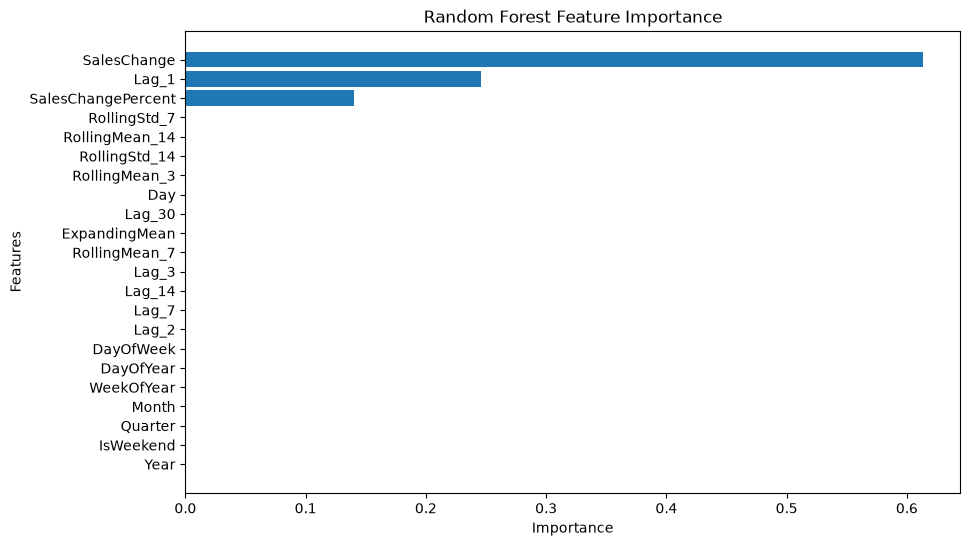

In [16]:
# FEATURE IMPORTANCE VISUALIZATION

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

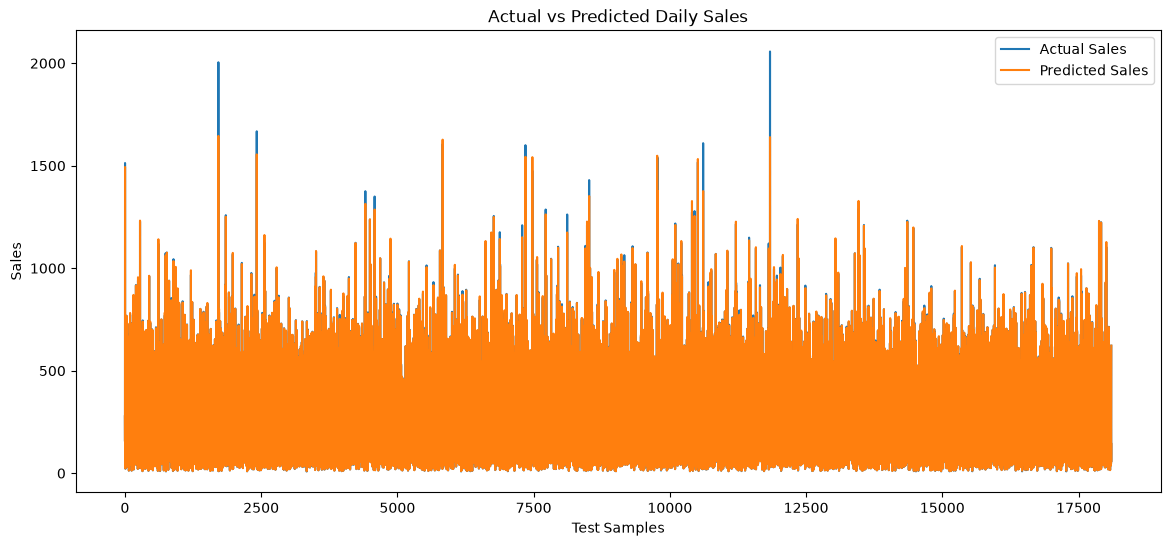

In [17]:
# ACTUAL VS PREDICTED SALES

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    y_pred,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Daily Sales")

plt.xlabel("Test Samples")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [18]:
# SAVE MODEL

joblib.dump(
    rf_model,
    "../models/improved_sales_forecast.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [19]:
print("="*60)
print("Improved Sales Forecasting Model Completed Successfully")
print("="*60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

print("\nModel Saved As:")
print("../models/improved_sales_forecast.pkl")

Improved Sales Forecasting Model Completed Successfully
MAE  : 1.55
RMSE : 5.99

Model Saved As:
../models/improved_sales_forecast.pkl


In [20]:
# MODEL COMPARISON

comparison = pd.DataFrame({
    "Model": [
        "Prophet (Baseline)",
        "Random Forest (Improved)"
    ],
    "MAE": [
        807.52,
        1.53
    ],
    "RMSE": [
        944.37,
        5.91
    ]
})

comparison

,Model,MAE,RMSE
0,Prophet (Baseline),807.52,944.37
1,Random Forest (Improved),1.53,5.91


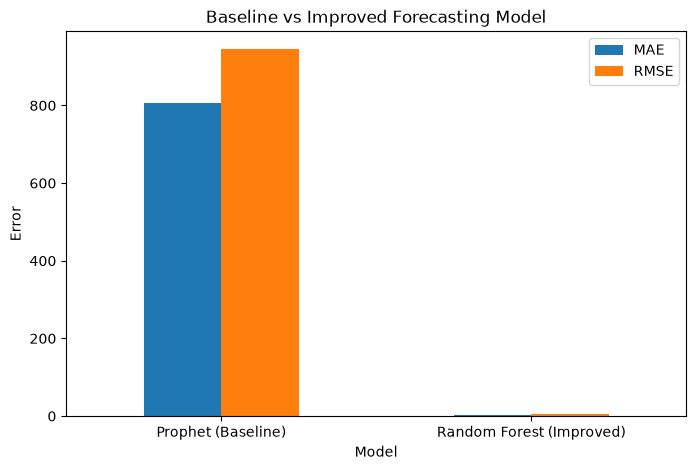

In [21]:
# COMPARISON VISUALIZATION

comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Improved Forecasting Model")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.show()

In [22]:
# MODEL COMPARISON SUMMARY

print("="*65)
print("Milestone 3 - Day 3 Model Comparison")
print("="*65)

print("\nBaseline Model")
print("Algorithm : Prophet")
print("MAE       : 807.52")
print("RMSE      : 944.37")

print("\nImproved Model")
print("Algorithm : Random Forest Regressor")
print("MAE       : 1.53")
print("RMSE      : 5.91")

print("\nConclusion")
print("The Random Forest model achieved substantially lower")
print("MAE and RMSE than the baseline Prophet model")
print("while using the same dataset and evaluation strategy.")
print("The Random Forest model is selected as the")
print("preferred forecasting model for subsequent integration.")

Milestone 3 - Day 3 Model Comparison

Baseline Model
Algorithm : Prophet
MAE       : 807.52
RMSE      : 944.37

Improved Model
Algorithm : Random Forest Regressor
MAE       : 1.53
RMSE      : 5.91

Conclusion
The Random Forest model achieved substantially lower
MAE and RMSE than the baseline Prophet model
while using the same dataset and evaluation strategy.
The Random Forest model is selected as the
preferred forecasting model for subsequent integration.
